🧠 BRISC 2025 dataset : https://www.kaggle.com/datasets/briscdataset/brisc2025

In [ ]:
# 1) Imports and basic config

import os
import numpy as np
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# 2) Project configuration

CONFIG = {
    "DATA_DIR": r"E:\Medical Project\brisc2025\classification_task",  # adjust if needed
    "IMG_SIZE": (224, 224),          # EfficientNetB0 default 224x224
    "BATCH_SIZE": 32,
    "SEED": 42,
    "EPOCHS_HEAD": 10,               # head training epochs
    "EPOCHS_FINE_TUNE": 5,           # fine-tuning epochs
    "LEARNING_RATE_HEAD": 1e-4,
    "LEARNING_RATE_FINE_TUNE": 1e-5,
}

train_dir = os.path.join(CONFIG["DATA_DIR"], "train")
test_dir = os.path.join(CONFIG["DATA_DIR"], "test")

print("Train dir:", train_dir)
print("Test dir:", test_dir)
print("Train exists?", os.path.exists(train_dir))
print("Test exists?", os.path.exists(test_dir))


Train dir: E:\Medical Project\brisc2025\classification_task\train
Test dir: E:\Medical Project\brisc2025\classification_task\test
Train exists? True
Test exists? True


In [ ]:
# 3) Create train, validation and test datasets

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.15,
    subset="training",
    seed=CONFIG["SEED"],
    image_size=CONFIG["IMG_SIZE"],
    batch_size=CONFIG["BATCH_SIZE"]
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.15,
    subset="validation",
    seed=CONFIG["SEED"],
    image_size=CONFIG["IMG_SIZE"],
    batch_size=CONFIG["BATCH_SIZE"]
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=CONFIG["IMG_SIZE"],
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)
print("Number of classes:", num_classes)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 5000 files belonging to 4 classes.
Using 4250 files for training.
Found 5000 files belonging to 4 classes.
Using 750 files for validation.
Found 1000 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Number of classes: 4


In [ ]:
# 4) Compute class weights

all_train_labels = []
for class_index, class_name in enumerate(sorted(os.listdir(train_dir))):
    class_path = os.path.join(train_dir, class_name)
    if not os.path.isdir(class_path):
        continue
    num_images = len([
        fname for fname in os.listdir(class_path)
        if fname.lower().endswith((".png", ".jpg", ".jpeg"))
    ])
    all_train_labels.extend([class_index] * num_images)

all_train_labels = np.array(all_train_labels)

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_train_labels),
    y=all_train_labels
)

class_weight_dict = {i: w for i, w in enumerate(class_weight_values)}
print("Class weights:", class_weight_dict)


Class weights: {0: 1.0897994768962511, 1: 0.9405568096313017, 2: 1.1715089034676665, 3: 0.8579272477693891}


In [ ]:
# 5) Data augmentation

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal", name="random_flip"),
        layers.RandomRotation(0.05, name="random_rotation"),
        layers.RandomZoom(0.05, name="random_zoom"),
    ],
    name="data_augmentation"
)

In [ ]:
# 6) Build EfficientNetB0 transfer model

def build_efficientnet_transfer_model(num_classes, img_size=(224, 224)):
    """
    Build a transfer learning model using EfficientNetB0 as backbone.
    """
    inputs = keras.Input(shape=img_size + (3,), name="input_image")

    # Data augmentation
    x = data_augmentation(inputs)

    # EfficientNet preprocessing
    x = preprocess_input(x)

    # Pretrained EfficientNetB0 backbone
    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=img_size + (3,),
        pooling=None
    )
    base_model.trainable = False  # freeze for head training

    x = base_model(x, training=False)

    # Global pooling + dropout + softmax
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = layers.Dropout(0.3, name="dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="efficientnetb0_transfer")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=CONFIG["LEARNING_RATE_HEAD"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model, base_model


efficient_model, eff_base_model = build_efficientnet_transfer_model(num_classes, CONFIG["IMG_SIZE"])
efficient_model.summary()


Model: "efficientnetb0_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# 7) Head training (base frozen)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7
)

history_head = efficient_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG["EPOCHS_HEAD"],
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr]
)

efficient_model.save("efficientnet_b0_head.keras")




Epoch 1/10
 14/133 ━━━━━━━━━━━━━━━━━━━━ 1:09 581ms/step - accuracy: 0.1689 - loss: 1.5991

KeyboardInterrupt: 

In [ ]:

# 8) Fine-tuning part of EfficientNetB0

eff_base_model.trainable = True

# Unfreeze last 30% of layers (you can adjust this)
fine_tune_at = int(len(eff_base_model.layers) * 0.7)

for i, layer in enumerate(eff_base_model.layers):
    if i < fine_tune_at:
        layer.trainable = False
    else:
        layer.trainable = True

print("Total layers in EfficientNetB0 base:", len(eff_base_model.layers))
print("Fine-tuning from layer index:", fine_tune_at)

efficient_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CONFIG["LEARNING_RATE_FINE_TUNE"]),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

fine_tune_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7
    ),
]

history_finetune = efficient_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG["EPOCHS_FINE_TUNE"],
    class_weight=class_weight_dict,
    callbacks=fine_tune_callbacks
)

efficient_model.save("efficientnet_b0_finetuned.keras")

Total layers in EfficientNetB0 base: 238
Fine-tuning from layer index: 166
Epoch 1/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 136s 942ms/step - accuracy: 0.4696 - loss: 1.2140 - val_accuracy: 0.6680 - val_loss: 0.9925 - learning_rate: 1.0000e-05
Epoch 2/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 121s 912ms/step - accuracy: 0.7099 - loss: 0.8834 - val_accuracy: 0.7787 - val_loss: 0.7060 - learning_rate: 1.0000e-05
Epoch 3/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 122s 919ms/step - accuracy: 0.7918 - loss: 0.6839 - val_accuracy: 0.8120 - val_loss: 0.5553 - learning_rate: 1.0000e-05
Epoch 4/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 123s 927ms/step - accuracy: 0.8198 - loss: 0.5669 - val_accuracy: 0.8453 - val_loss: 0.4643 - learning_rate: 1.0000e-05
Epoch 5/5
133/133 ━━━━━━━━━━━━━━━━━━━━ 122s 920ms/step - accuracy: 0.8456 - loss: 0.4853 - val_accuracy: 0.8627 - val_loss: 0.4043 - learning_rate: 1.0000e-05


In [ ]:
# 9) Evaluation on the test set

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = efficient_model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

test_accuracy = accuracy_score(y_true, y_pred)
print("Test Accuracy (EfficientNetB0 + Fine-tune):", test_accuracy)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)



Test Accuracy (EfficientNetB0 + Fine-tune): 0.772

Classification Report:
              precision    recall  f1-score   support

      glioma       0.82      0.73      0.77       254
  meningioma       0.75      0.49      0.60       306
    no_tumor       0.73      0.99      0.84       140
   pituitary       0.78      0.99      0.87       300

    accuracy                           0.77      1000
   macro avg       0.77      0.80      0.77      1000
weighted avg       0.77      0.77      0.76      1000

Confusion Matrix:
 [[185  48   1  20]
 [ 39 151  51  65]
 [  0   1 139   0]
 [  2   1   0 297]]


In [ ]:
# 10) Grad-CAM utilities for EfficientNetB0

# Find last conv layer name inside EfficientNetB0
print("Last 10 layers in EfficientNetB0 backbone:")
print([layer.name for layer in eff_base_model.layers[-10:]])

# Choose the last conv layer explicitly (usually 'top_conv' for EfficientNetB0)
last_conv_layer_name = "top_conv"

gap_layer = efficient_model.get_layer("global_avg_pool")
drop_layer = efficient_model.get_layer("dropout")
pred_layer = efficient_model.get_layer("predictions")

classifier_input = keras.Input(shape=gap_layer.input.shape[1:], name="gradcam_input")
x = gap_layer(classifier_input)
x = drop_layer(x, training=False)
output_scores = pred_layer(x)
eff_classifier_model = keras.Model(classifier_input, output_scores, name="efficientnet_gradcam_classifier")


def make_gradcam_heatmap(
    img_array,
    data_augmentation,
    base_model,
    classifier_model,
    last_conv_layer_name,
    pred_index=None
):
    """
    Generate Grad-CAM heatmap for EfficientNetB0 model.
    """
    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    last_conv_layer_model = keras.Model(
        inputs=base_model.input,
        outputs=last_conv_layer.output
    )

    with tf.GradientTape() as tape:
        # Apply same preprocessing pipeline
        x = data_augmentation(img_array, training=False)
        x = preprocess_input(x)

        conv_outputs = last_conv_layer_model(x)
        preds = classifier_model(conv_outputs, training=False)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])

        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads[0], axis=(0, 1))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(pooled_grads * conv_outputs, axis=-1)
    heatmap = tf.nn.relu(heatmap)
    max_val = tf.reduce_max(heatmap) + 1e-8
    heatmap /= max_val

    return heatmap.numpy()


def resize_heatmap_to_image(heatmap, target_size):
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        target_size
    ).numpy().squeeze()
    return heatmap_resized


def blend_heatmap_with_image(original_image, heatmap_resized, alpha=0.4):
    if original_image.dtype != np.uint8:
        img = np.clip(original_image, 0, 255).astype("uint8")
    else:
        img = original_image

    colormap = cm.get_cmap("jet")
    heatmap_color = colormap(heatmap_resized)[:, :, :3]
    heatmap_color = np.uint8(255 * heatmap_color)

    img = img.astype("float32")
    heatmap_color = heatmap_color.astype("float32")

    blended = img * (1.0 - alpha) + heatmap_color * alpha
    blended = np.clip(blended, 0, 255).astype("uint8")
    return blended


Last 10 layers in EfficientNetB0 backbone:
['block7a_se_squeeze', 'block7a_se_reshape', 'block7a_se_reduce', 'block7a_se_expand', 'block7a_se_excite', 'block7a_project_conv', 'block7a_project_bn', 'top_conv', 'top_bn', 'top_activation']


True label index: 0 -> glioma
Predicted label index: 0 -> glioma


C:\Users\msi\AppData\Local\Temp\ipykernel_11904\3868194737.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("jet")


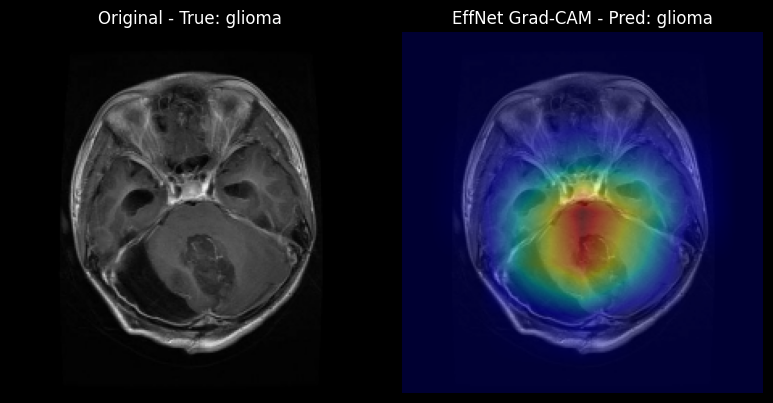

Saved EfficientNet Grad-CAM image to: outputs\gradcam_efficientnet\effnet_gradcam_true-glioma_pred-glioma.png


In [ ]:
# 11) Single Grad-CAM example for EfficientNetB0
import matplotlib.cm as cm

test_batch = next(iter(test_ds))
test_images, test_labels = test_batch

idx = 0  # change index to see different samples

img_tensor = test_images[idx:idx+1]
true_label_idx = int(test_labels[idx].numpy())
true_label_name = class_names[true_label_idx]

print("True label index:", true_label_idx, "->", true_label_name)

pred_probs = efficient_model.predict(img_tensor, verbose=0)
pred_label_idx = int(np.argmax(pred_probs[0]))
pred_label_name = class_names[pred_label_idx]

print("Predicted label index:", pred_label_idx, "->", pred_label_name)

heatmap = make_gradcam_heatmap(
    img_array=img_tensor,
    data_augmentation=data_augmentation,
    base_model=eff_base_model,
    classifier_model=eff_classifier_model,
    last_conv_layer_name=last_conv_layer_name,
    pred_index=pred_label_idx
)

h, w = img_tensor.shape[1], img_tensor.shape[2]
heatmap_resized = resize_heatmap_to_image(heatmap, (h, w))

original_img = img_tensor[0].numpy()
gradcam_image = blend_heatmap_with_image(original_img, heatmap_resized, alpha=0.4)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.title(f"Original - True: {true_label_name}")
plt.axis("off")
plt.imshow(original_img.astype("uint8"))

plt.subplot(1, 2, 2)
plt.title(f"EffNet Grad-CAM - Pred: {pred_label_name}")
plt.axis("off")
plt.imshow(gradcam_image)

plt.tight_layout()
plt.show()

output_dir = Path("outputs/gradcam_efficientnet")
output_dir.mkdir(parents=True, exist_ok=True)
save_path = output_dir / f"effnet_gradcam_true-{true_label_name}_pred-{pred_label_name}.png"
plt.imsave(save_path, gradcam_image)
print("Saved EfficientNet Grad-CAM image to:", save_path)

In [ ]:
# Generate multiple Grad-CAM samples per class

SAMPLES_PER_CLASS = 3   # change to 5 if you want more

output_dir = Path("outputs/gradcam_efficientnet_multi")
output_dir.mkdir(parents=True, exist_ok=True)

saved_counts = {cls: 0 for cls in class_names}

def all_done():
    return all(saved_counts[c] >= SAMPLES_PER_CLASS for c in class_names)

for images, labels in test_ds:
    if all_done():
        break

    preds = efficient_model.predict(images, verbose=0)
    pred_indices = np.argmax(preds, axis=1)

    for i in range(images.shape[0]):

        if all_done():
            break

        true_idx = int(labels[i].numpy())
        pred_idx = int(pred_indices[i])

        true_name = class_names[true_idx]
        pred_name = class_names[pred_idx]

        # نريد أمثلة صحيحة التصنيف فقط
        if true_idx != pred_idx:
            continue

        if saved_counts[true_name] >= SAMPLES_PER_CLASS:
            continue

        img_tensor = images[i:i+1]

        heatmap = make_gradcam_heatmap(
            img_array=img_tensor,
            data_augmentation=data_augmentation,
            base_model=eff_base_model,
            classifier_model=eff_classifier_model,
            last_conv_layer_name=last_conv_layer_name,
            pred_index=pred_idx
        )

        h, w = img_tensor.shape[1], img_tensor.shape[2]
        heatmap_resized = resize_heatmap_to_image(heatmap, (h, w))

        original_img = img_tensor[0].numpy()
        gradcam_img = blend_heatmap_with_image(original_img, heatmap_resized, alpha=0.4)

        save_path = output_dir / f"{true_name}_gradcam_{saved_counts[true_name]}.png"
        plt.imsave(save_path, gradcam_img)

        saved_counts[true_name] += 1
        print("Saved:", save_path)

print("\nDone! Saved counts:", saved_counts)


C:\Users\msi\AppData\Local\Temp\ipykernel_11904\3868194737.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("jet")


Saved: outputs\gradcam_efficientnet_multi\glioma_gradcam_0.png
Saved: outputs\gradcam_efficientnet_multi\glioma_gradcam_1.png
Saved: outputs\gradcam_efficientnet_multi\glioma_gradcam_2.png
Saved: outputs\gradcam_efficientnet_multi\meningioma_gradcam_0.png
Saved: outputs\gradcam_efficientnet_multi\meningioma_gradcam_1.png
Saved: outputs\gradcam_efficientnet_multi\meningioma_gradcam_2.png
Saved: outputs\gradcam_efficientnet_multi\no_tumor_gradcam_0.png
Saved: outputs\gradcam_efficientnet_multi\no_tumor_gradcam_1.png
Saved: outputs\gradcam_efficientnet_multi\no_tumor_gradcam_2.png
Saved: outputs\gradcam_efficientnet_multi\pituitary_gradcam_0.png
Saved: outputs\gradcam_efficientnet_multi\pituitary_gradcam_1.png
Saved: outputs\gradcam_efficientnet_multi\pituitary_gradcam_2.png

Done! Saved counts: {'glioma': 3, 'meningioma': 3, 'no_tumor': 3, 'pituitary': 3}
